> **Purpose:** The birth–death pool of `eta_by_operator`, looked at instead of summarised — three trees across the imbalance range, each with its four matrices, its two spectra and its two classifying vectors, then the pooled 200-tree distributions.
> **Data:** generated (birth–death, `birth_rate=0.5`, `death_rate=0`, n=1000, L=10⁴)

# The birth–death model, up close

`eta_by_operator` runs both tree models but every single-tree exhibit in it is a
**Kingman** tree. The birth–death pool is where the two routes come apart:

| | valid tree edge | median η | `√m δ_*` of `u⁽¹⁾` |
|---|---|---|---|
| Kingman | 98.6% (`B`) | 1.85 | 0.36 |
| birth–death | 55.5% (`B`) | 1.53 | 0.024 |

Those are pooled scalars. This notebook shows the objects behind them.

- **`L(S)`** — Fiedler vector of `Deg(S) − S`, split by k-means on the entries.
- **`B`** — leading-|λ| eigenvector `u⁽¹⁾` of `H D H`, `D = −log S`, split by sign.
- **η** = larger clan / smaller clan; **valid** = the split is a genuine single-edge
  bipartition of the true tree.

Kingman appears only as a reference: as text beside the birth–death medians, and as a
grey outline over the pooled vector histograms. Nothing here writes a figure asset.

Drawing code is `analysis/utils/operator_exhibit.py`; the screen and the two 200-tree
caches are the committed ones under `analysis/notebooks_cache/eta_by_operator/`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_root = Path.cwd()
while not (_root / "analysis").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

from analysis.utils.eta_screen import MIN_SPLIT, run_eta_screen
from analysis.utils.operator_exhibit import (C_MOD, build_exhibit, draw_matrices,
                                             draw_spectra, draw_tree_pair,
                                             orient_minority, relative_gaps)
from src.core.utils import compute_fiedler_from_laplacian, compute_laplacian
from src.models.generated_trees import make_generated
from src.runners.p_sweep_inner import _kmeans_bipartition
from src.utils.griffing import griffing_centered, griffing_leading_eigvec
from src.utils.tree_ids import build_ids

N, SEQ_LEN, COUNT = 1000, 10_000, 1000
MODEL, MNAME = "bd", "birth-death"
ARMS = [("S", r"$L(S)$, k-means"), ("B", r"$B=H\mathcal{D}H$, sign")]
CDIR = _root / "analysis" / "notebooks_cache" / "eta_by_operator"

# BOTH models are loaded even though only birth-death is drawn. The 200-tree spectra
# and vector caches further down are keyed by ids drawn from ONE rng over BOTH pools
# in this order; pruning this loop to 'bd' changes the draw, misses the cache and
# silently starts a 17-minute recompute.
MODELS = [("kingman", "Kingman"), ("bd", MNAME)]

frames = []
for model, _ in MODELS:
    ids = build_ids(models=[model], n_values=[N], per_cell=COUNT)
    rows = run_eta_screen(ids, CDIR / f"{model}_n{N}_L{SEQ_LEN}.npz",
                          seq_len=SEQ_LEN, workers=6)
    f = pd.DataFrame([r for r in rows if "error" not in r])
    f["model"] = model
    frames.append(f)
df = pd.concat(frames, ignore_index=True)
dfb = df[df.model == MODEL]
print(f"\n{len(dfb)} {MNAME} trees, n={N}, L={SEQ_LEN}   "
      f"({len(df) - len(dfb)} Kingman trees loaded for the reference numbers only)")

cache: 1000 rows in kingman_n1000_L10000.npz
nothing to do -- all ids cached
cache: 1000 rows in bd_n1000_L10000.npz
nothing to do -- all ids cached

1000 birth-death trees, n=1000, L=10000   (1000 Kingman trees loaded for the reference numbers only)


In [2]:
# The pool this notebook is about, both routes, one row each.
summary = []
for tag, aname in ARMS:
    e, v = dfb[f"eta_{tag}"], dfb[f"valid_{tag}"]
    ek, vk = df[df.model == "kingman"][f"eta_{tag}"], df[df.model == "kingman"][f"valid_{tag}"]
    summary.append({
        "operator": aname,
        "valid": f"{int(v.sum())}/{len(dfb)}",
        "valid %": round(100 * v.mean(), 1),
        "median eta": round(float(e.median()), 2),
        "90th pct": round(float(e.quantile(0.90)), 1),
        "max eta": round(float(e.max()), 1),
        "Kingman valid %": round(100 * vk.mean(), 1),
        "Kingman median eta": round(float(ek.median()), 2),
    })
pd.DataFrame(summary).set_index("operator")

,valid,valid %,median eta,90th pct,max eta,Kingman valid %,Kingman median eta
operator,,,,,,,
"$L(S)$, k-means",996/1000,99.6,3.08,25.4,999.0,99.6,3.00
"$B=H\mathcal{D}H$, sign",555/1000,55.5,1.53,2.8,5.3,98.6,1.85


## Three trees across the imbalance range

One tree proves nothing and the extremes prove less, so the exhibits below are the
**nearest-rank q10, median and q90 of `η_B`** in the 1000-tree birth–death pool — the
balanced end, the typical tree, and the imbalanced end, none of them a single outlier
standing in for the pool.

`make_generated` is deterministic in the tree id, so each rebuild is the same tree the
screen saw; the assertions below check that by reproducing the screened `η` and
validity before anything is drawn.

In [ ]:
# Nearest-rank quantiles of eta_B, not min/max: the extremes of a 1000-tree pool are
# by construction the least representative trees in it.
QUANTS = [(0.10, "q10 - balanced end"), (0.50, "median"), (0.90, "q90 - imbalanced end")]
order = dfb.sort_values("eta_B").reset_index(drop=True)

TREE_IDS, LABELS = [], []
for q, name in QUANTS:
    r = order.iloc[min(int(q * len(order)), len(order) - 1)]
    TREE_IDS.append(str(r.tree))
    LABELS.append(rf"{name}:  $\eta_B$={r.eta_B:.2f}")
assert len(set(TREE_IDS)) == len(TREE_IDS), TREE_IDS

EX = []
for tid, lab in zip(TREE_IDS, LABELS):
    row = dfb[dfb.tree == tid].iloc[0]
    ex = build_exhibit(tid, SEQ_LEN)
    # the exhibit is only worth looking at if it reproduces the screened row
    for tag in ("S", "B"):
        assert np.isclose(ex.eta(tag), row[f"eta_{tag}"]), (tid, tag)
        assert ex.valid(tag) == row[f"valid_{tag}"], (tid, tag)
    EX.append(ex)
    agree = float(np.mean(ex.part_S == ex.part_B))
    print(f"{tid:>16s}  eta_S={row.eta_S:8.2f} (valid={str(row.valid_S):5s})  "
          f"eta_B={row.eta_B:8.2f} (valid={str(row.valid_B):5s})  "
          f"leaf agreement between the two splits {max(agree, 1 - agree):.1%}")

### The trees and the two vectors

Each tree is drawn twice from its own patristic distances — once per operator — with
the vector alongside. A clade is blue or orange when every leaf below it falls on one
side of that operator's split and grey when it straddles the cut, so a partition is a
real tree edge exactly when the grey reduces to a single path to the root.

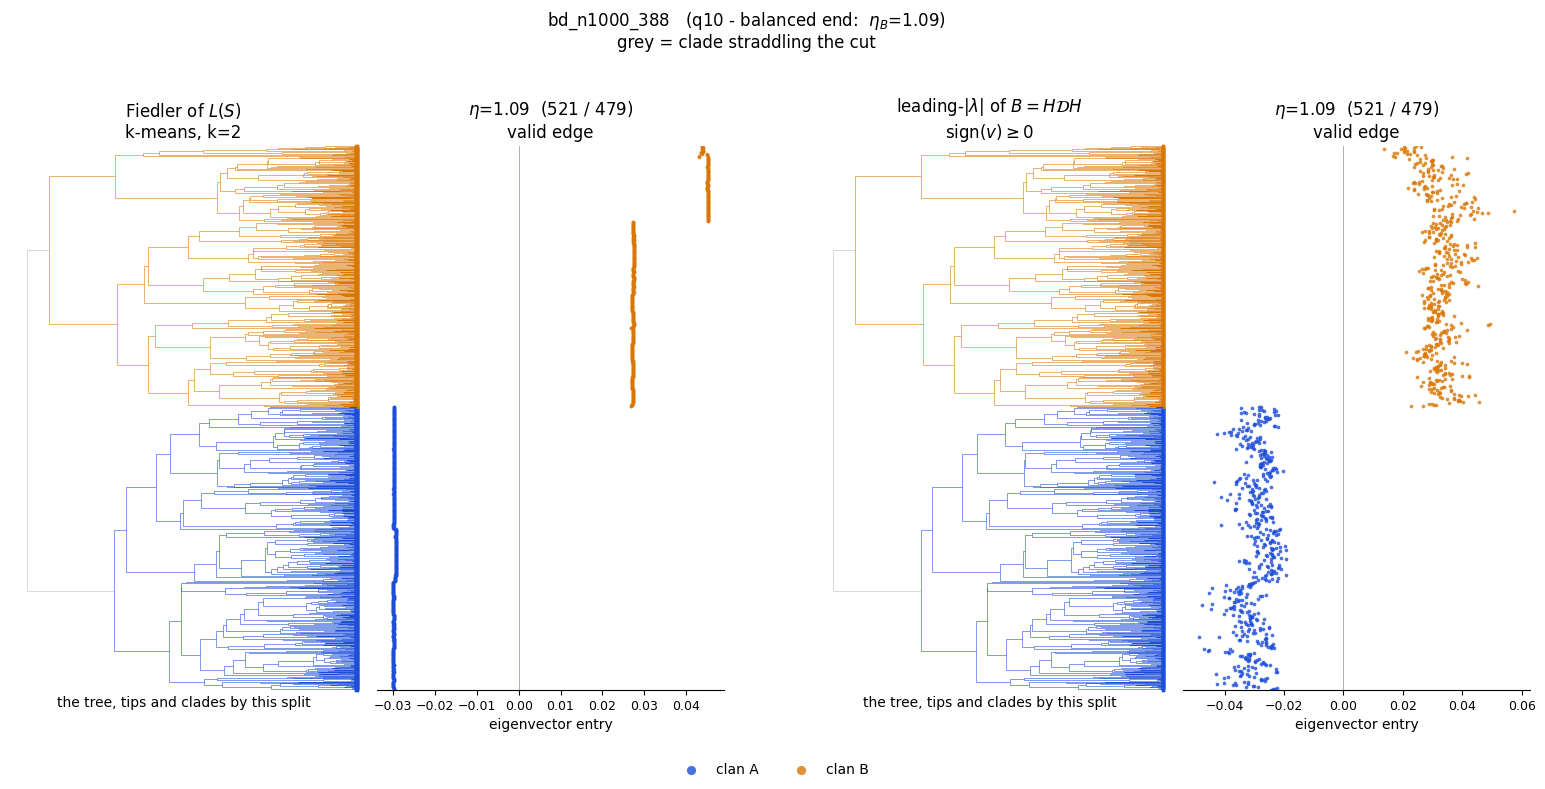

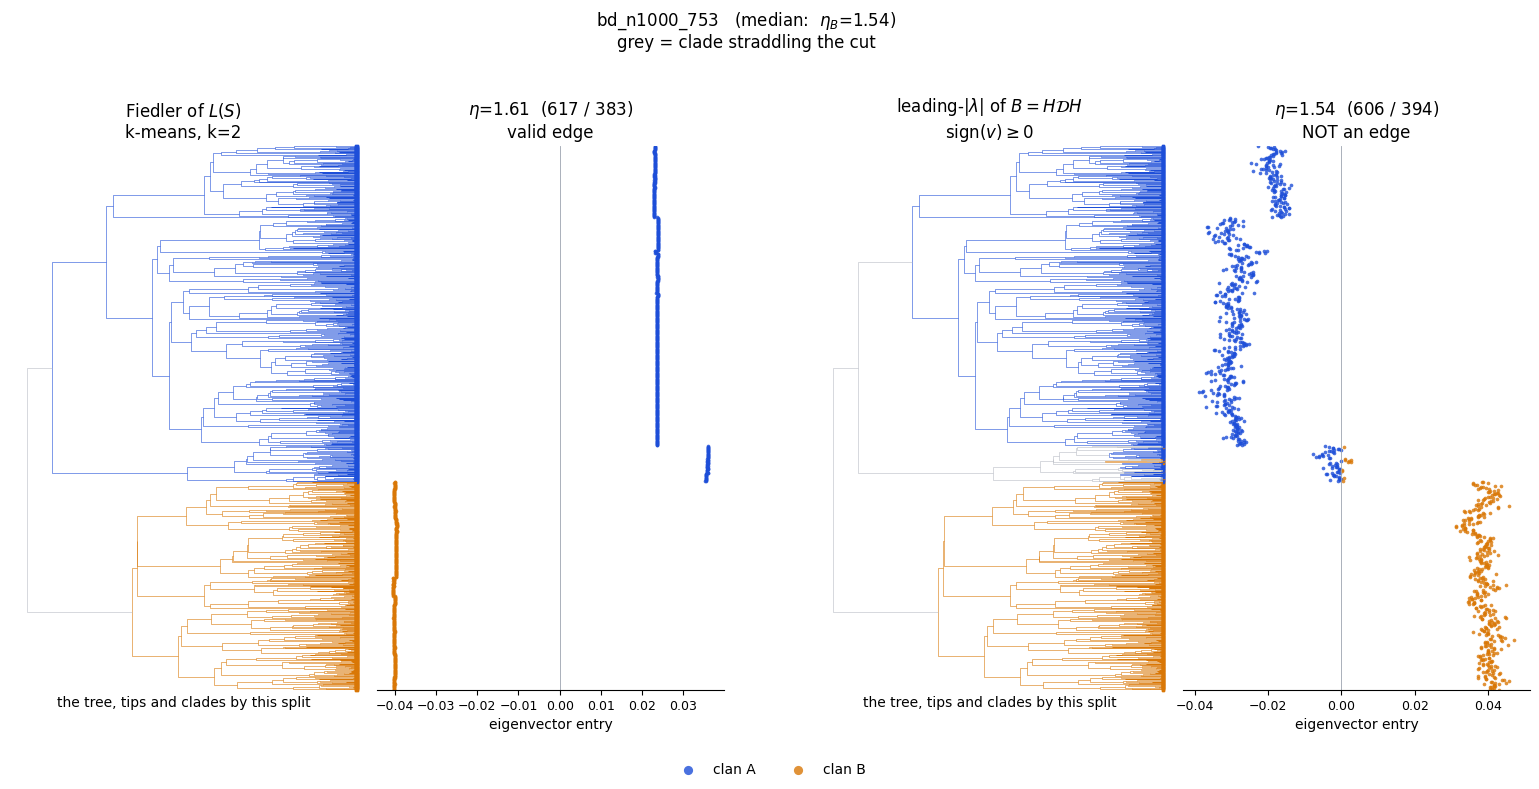

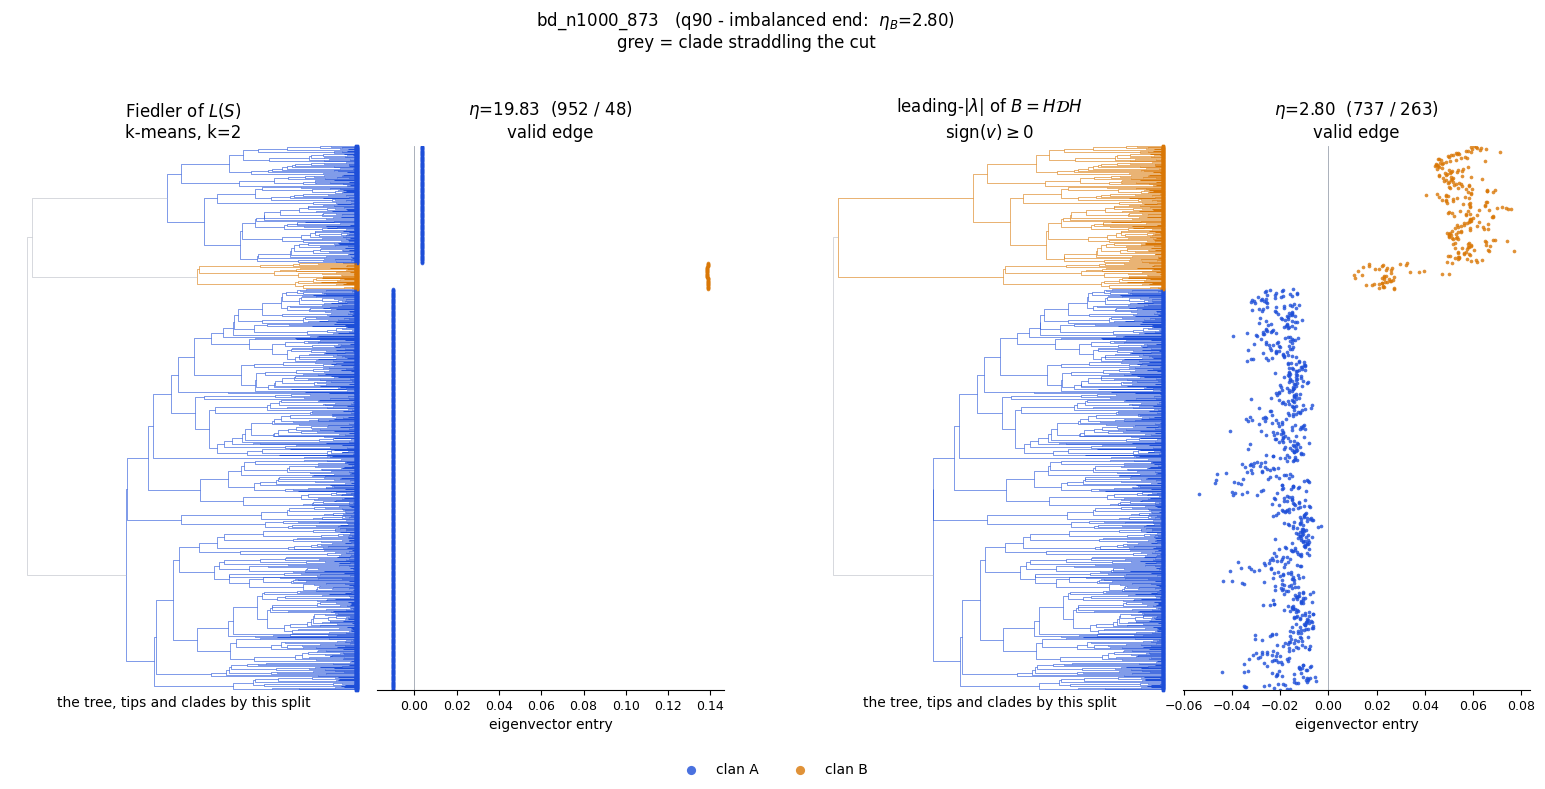

In [ ]:
for ex, lab in zip(EX, LABELS):
    fig = draw_tree_pair(ex)
    fig.suptitle(f"{ex.tree_id}   ({lab})\ngrey = clade straddling the cut",
                 fontsize=12, y=0.97)
    plt.show()

### The matrices the vectors come from

`S`, its Laplacian, the distance `D = −log S` and Griffing's centred `B = H D H`, one
row per tree, leaves in the same order as the plots above so a clan of the true tree
is a contiguous block. **Each panel is scaled separately** — their ranges differ by
orders of magnitude — and the sub-title of every panel states the norm it uses.

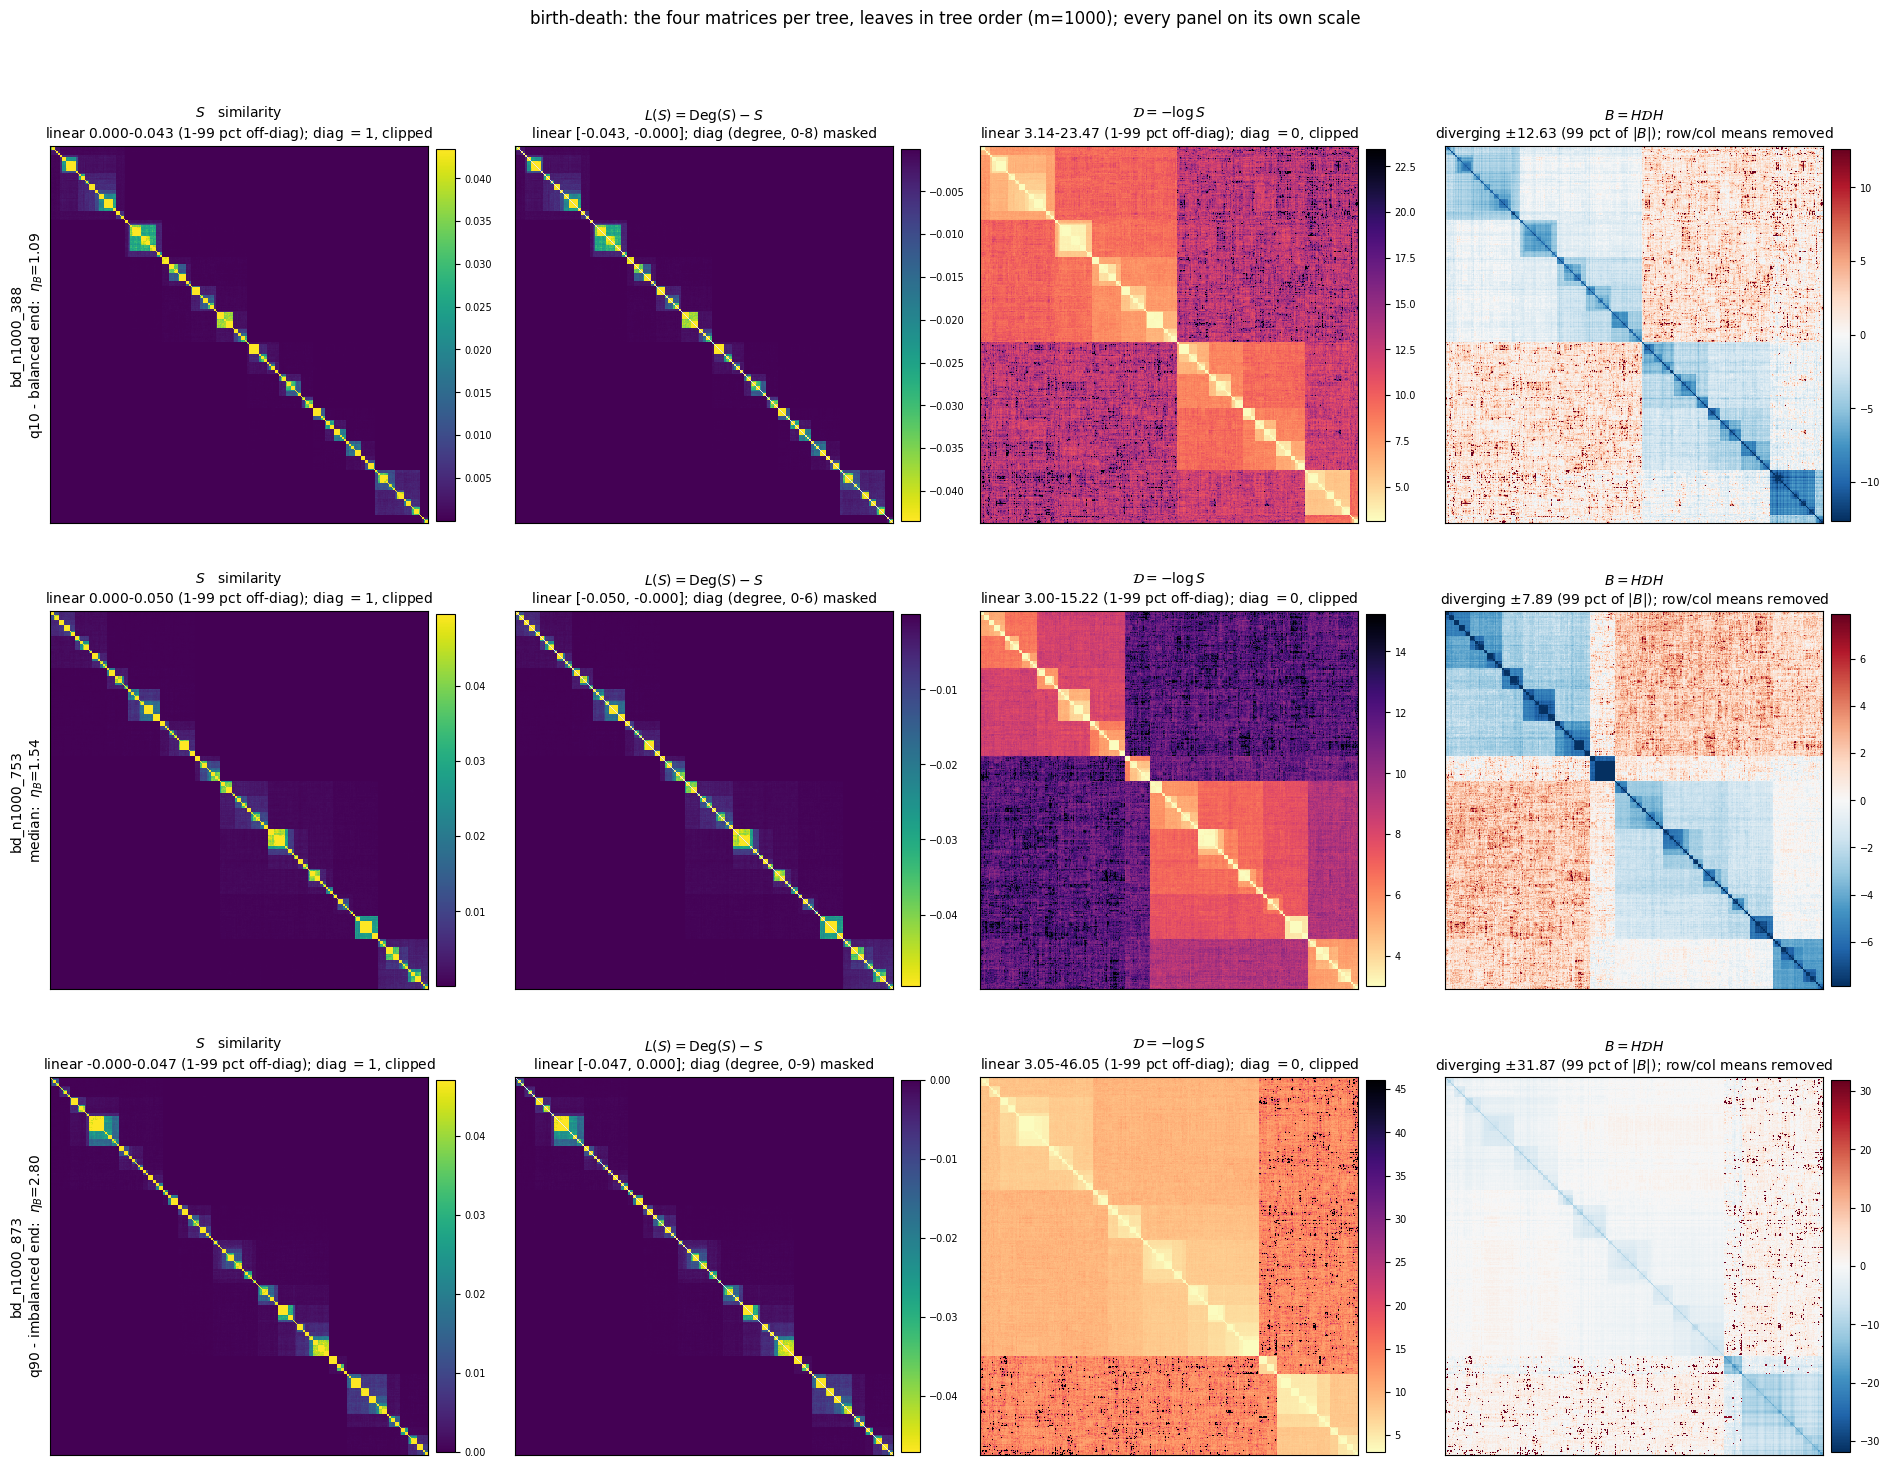

min           max  off-diag mean  off-diag sd
tree         matrix                                                        
bd_n1000_388 S      -1.786242e-06  1.000000e+00       0.002715     0.028535
             L      -1.000000e+00  1.786242e-06      -0.002715     0.028535
             D      -0.000000e+00  4.605170e+01      11.576515     4.475336
             B      -1.778784e+01  3.552512e+01       0.011577     4.371355
bd_n1000_753 S      -2.788717e-07  1.000000e+00       0.003049     0.029832
             L      -1.000000e+00  2.788717e-07      -0.003049     0.029832
             D      -0.000000e+00  4.605170e+01      10.021491     2.796266
             B      -1.377317e+01  3.632949e+01       0.010021     2.674873
bd_n1000_873 S      -4.855426e-06  1.000000e+00       0.002737     0.028617
             L      -1.000000e+00  4.855426e-06      -0.002737     0.028617
             D      -0.000000e+00  4.605170e+01      11.196663     5.381732
             B      -2.259318e+01  3.556251e+01       0.011197     4.900606

In [ ]:
fig, axes = plt.subplots(len(EX), 4, figsize=(19, 5.1 * len(EX)))
stats = []
for r, (ex, lab) in enumerate(zip(EX, LABELS)):
    for st in draw_matrices(ex, axes[r], fig):
        st["tree"] = ex.tree_id
        stats.append(st)
    axes[r, 0].set_ylabel(f"{ex.tree_id}\n{lab}", fontsize=10)
fig.suptitle(f"{MNAME}: the four matrices per tree, leaves in tree order (m={EX[0].m}); "
             f"every panel on its own scale", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# L's off-diagonal is exactly -S, so the only thing the Laplacian adds to the
# similarity is on the diagonal: the degree, which is the row sum of S.
pd.DataFrame(stats).set_index(["tree", "matrix"])

### The two spectra

The signal each route actually has to work with: the leading eigenvalues of the two
operators, ordered the way that route reads them — `L(S)` ascending (it wants the
second smallest, the Fiedler value) and `B` by decreasing `|λ|` (it wants the largest,
which for a raw distance matrix is the most negative). The red circle marks the
eigenvalue whose eigenvector that route partitions on; the inset zooms on the head,
where `λ₁ = 0` and the bulk would otherwise hide the gaps that matter.

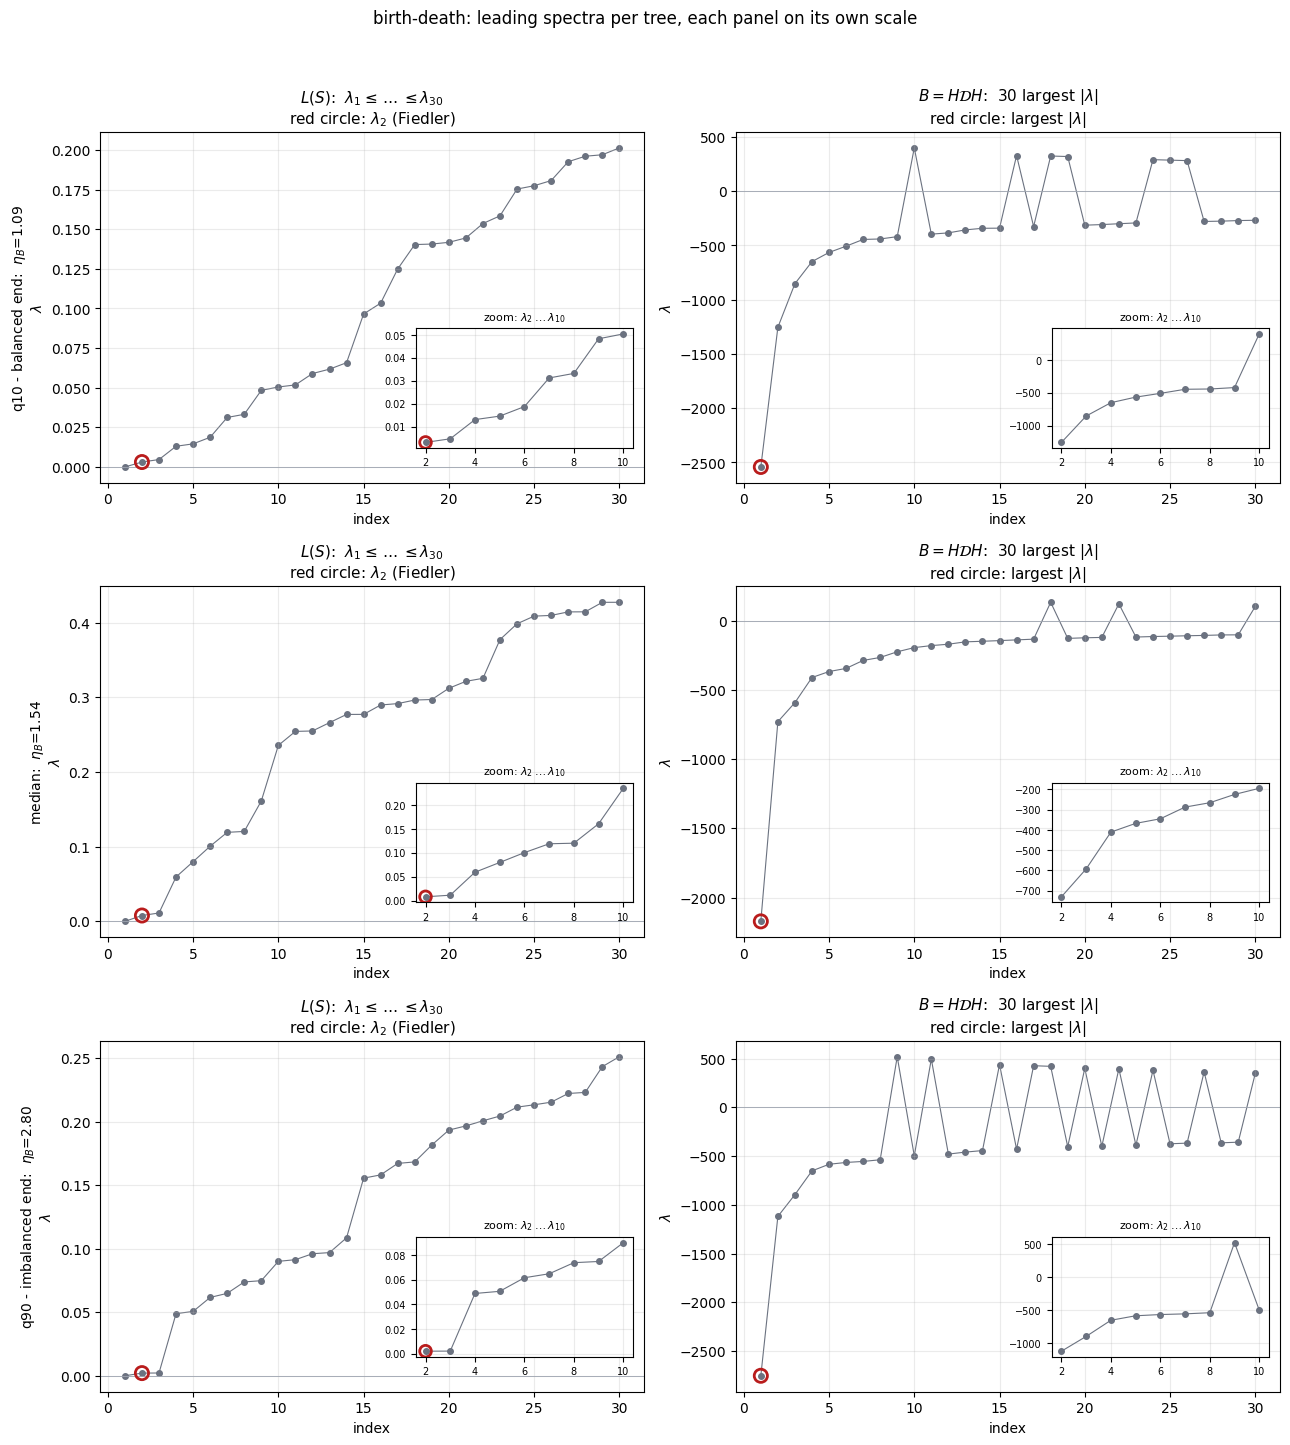

,label,L(S) lambda_2,L(S) (l3-l2)/l3,B |lambda_1|,B (|l1|-|l2|)/|l1|
tree,,,,,
bd_n1000_388,q10 - balanced end: \eta_B=1.09,0.003113,0.3350,2541,0.5064
bd_n1000_753,median: \eta_B=1.54,0.007841,0.3003,2171,0.6639
bd_n1000_873,q90 - imbalanced end: \eta_B=2.80,0.002095,0.0398,2753,0.5937


In [ ]:
fig, axes = plt.subplots(len(EX), 2, figsize=(13, 4.9 * len(EX)))
gap_rows = []
for r, (ex, lab) in enumerate(zip(EX, LABELS)):
    ev_L, ev_B = draw_spectra(ex, axes[r])
    g_L, g_B = relative_gaps(ev_L, ev_B)
    axes[r, 0].set_ylabel(f"{lab}\n" + r"$\lambda$", fontsize=10)
    gap_rows.append({"tree": ex.tree_id, "label": lab.replace("$", ""),
                     "L(S) lambda_2": f"{ev_L[1]:.4g}",
                     "L(S) (l3-l2)/l3": round(g_L, 4),
                     "B |lambda_1|": f"{abs(ev_B[0]):.4g}",
                     "B (|l1|-|l2|)/|l1|": round(g_B, 4)})
fig.suptitle(f"{MNAME}: leading spectra per tree, each panel on its own scale",
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# The gap next to the eigenvector a route uses is the whole story of how stable that
# split is: a small relative gap means a sub-sample can rotate the vector out of it.
pd.DataFrame(gap_rows).set_index("tree")

## Are those three representative?

The same 200 trees per model that `eta_by_operator` caches, restricted to the
birth–death half. Two committed caches carry them, and both are keyed by an id list
drawn over **both** pools in one pass — the cell asserts the ids match rather than
falling through to a recompute.

The band plot is the mean spectrum point by point with a ±1 sd band; the histograms
are the distributions of the two eigenvalues each route actually reads. Kingman
medians are printed beside the birth–death ones rather than drawn: `λ₂(L_S)` differs
between the models by four orders of magnitude, so a shared axis would flatten the
panel.

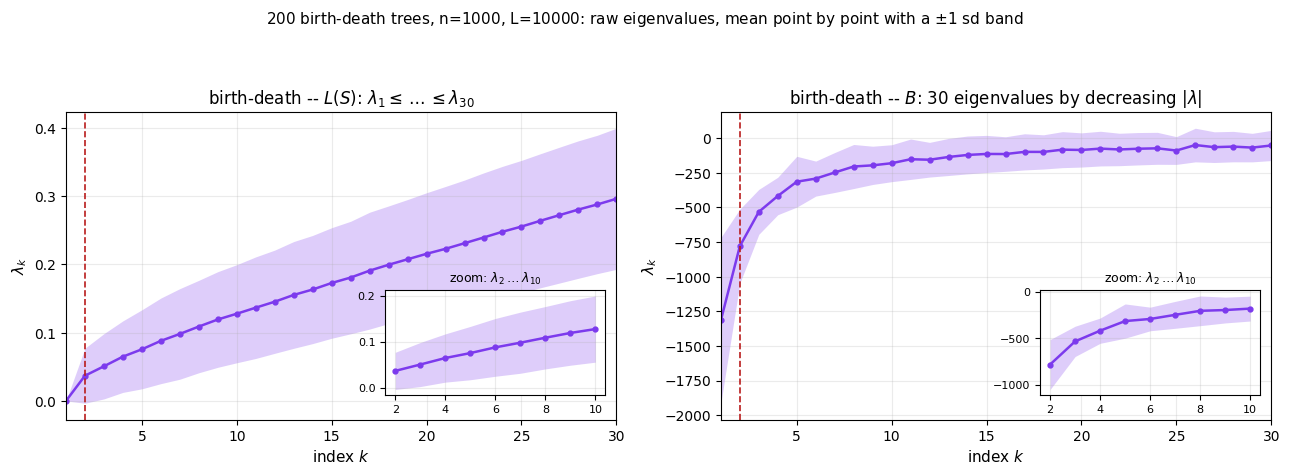

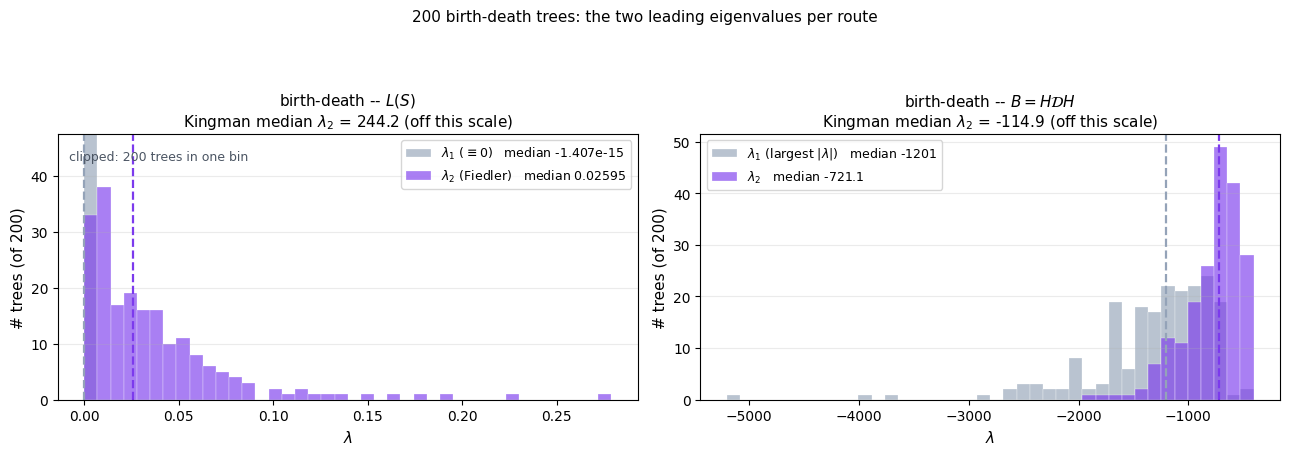

Kingman       median relative gap:  L(S) (l3-l2)/l3 = 0.196   B (|l1|-|l2|)/|l1| = 0.602
birth-death   median relative gap:  L(S) (l3-l2)/l3 = 0.253   B (|l1|-|l2|)/|l1| = 0.375


In [ ]:
K, K_PLOT, R_SAMPLE = 50, 30, 200
SPEC_CACHE = CDIR / f"spectra_sample_n{N}_L{SEQ_LEN}_R{R_SAMPLE}.npz"

# The draw that keys both caches: one rng, both pools, kingman first. Do not change.
rng = np.random.default_rng(0)
sample_ids = np.asarray(np.concatenate(
    [rng.choice(np.sort(df[df.model == mo]["tree"].values), R_SAMPLE, replace=False)
     for mo, _ in MODELS]), dtype="U")
models = np.repeat([mo for mo, _ in MODELS], R_SAMPLE)

cached = np.load(SPEC_CACHE, allow_pickle=False)
assert np.array_equal(cached["ids"], sample_ids), (
    "spectra cache ids do not match the draw; recomputing is ~9 min, so this is "
    "raised rather than silently recomputed")
spec_L, spec_B = cached["spec_L"], cached["spec_B"]
sel, sel_k = models == MODEL, models == "kingman"

kk = np.arange(1, K_PLOT + 1)
ARM_SPEC = [(spec_L, rf"$L(S)$: $\lambda_1 \leq \dots \leq \lambda_{{{K_PLOT}}}$"),
            (spec_B, rf"$B$: {K_PLOT} eigenvalues by decreasing $|\lambda|$")]


def pad_lim(lohi, frac=0.06):
    """A y-range with a little air, so a clipped percentile band is not flush."""
    lo, hi = float(lohi[0]), float(lohi[1])
    pad = frac * (hi - lo) or 1e-12
    return lo - pad, hi + pad


def band(ax_, x, block, color):
    """Mean point by point, with a +/- 1 sd band around it."""
    mu, sd = block.mean(axis=0), block.std(axis=0)
    ax_.fill_between(x, mu - sd, mu + sd, color=color, alpha=0.25, lw=0)
    ax_.plot(x, mu, "o-", ms=3.5, lw=1.8, color=color)
    return float((mu - sd).min()), float((mu + sd).max())


fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, (Y, name) in zip(axes, ARM_SPEC):
    Yv = Y[sel][:, :K_PLOT]
    ax.set_ylim(*pad_lim(band(ax, kk, Yv, C_MOD[MODEL])))
    ax.axvline(2, color="#b91c1c", ls="--", lw=1.2)
    ax.set_title(f"{MNAME} -- {name}", fontsize=12)
    ax.set_xlabel("index $k$", fontsize=11)
    ax.set_ylabel(r"$\lambda_k$", fontsize=11)
    ax.set_xlim(1, K_PLOT)
    ax.grid(alpha=0.25)
    axi = ax.inset_axes([0.58, 0.08, 0.40, 0.34])       # flush bottom-right
    axi.set_ylim(*pad_lim(band(axi, kk[1:10], Yv[:, 1:10], C_MOD[MODEL])))
    axi.set_title(r"zoom: $\lambda_{2}\dots\lambda_{10}$", fontsize=9)
    axi.set_xticks(np.arange(2, 11, 2))
    axi.tick_params(labelsize=8)
    axi.grid(alpha=0.25)
fig.suptitle(f"{R_SAMPLE} {MNAME} trees, n={N}, L={SEQ_LEN}: raw eigenvalues, mean "
             f"point by point with a $\\pm$1 sd band", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# The distributions of the two eigenvalues each route reads. For L(S), lambda_1 is
# identically 0 on a connected graph, so that series is a spike at the left edge and
# the content is lambda_2; for B both are negative (B is NSD) and the distance
# between the two clouds IS the gap the sign rule depends on.
C_EV1 = "#94a3b8"                       # lambda_1 grey; lambda_2 takes the model colour
EV_SPEC = [(spec_L, r"$L(S)$", (r"$\lambda_1$ ($\equiv 0$)", r"$\lambda_2$ (Fiedler)")),
           (spec_B, r"$B = H\mathcal{D}H$",
            (r"$\lambda_1$ (largest $|\lambda|$)", r"$\lambda_2$"))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, (Y, rname, labels) in zip(axes, EV_SPEC):
    e1, e2 = Y[sel, 0], Y[sel, 1]
    lo, hi_ = float(min(e1.min(), e2.min())), float(max(e1.max(), e2.max()))
    ebins = np.linspace(lo, hi_ + 1e-12 * max(abs(hi_), 1), 41)
    peaks = []
    for ev, col, lab in ((e1, C_EV1, labels[0]), (e2, C_MOD[MODEL], labels[1])):
        cnt, _, _ = ax.hist(ev, bins=ebins, color=col, alpha=0.65, edgecolor="white",
                            lw=0.3, label=f"{lab}   median {np.median(ev):.4g}")
        ax.axvline(float(np.median(ev)), color=col, ls="--", lw=1.6)
        peaks.append(int(cnt.max()))
    # L(S)'s lambda_1 is 0 for every tree, so its bar is the whole sample in one bin
    # and it flattens lambda_2 to nothing. Scale to the other series and say in the
    # axes how tall the clipped bar really is.
    if max(peaks) > 4 * min(peaks):
        ax.set_ylim(0, min(peaks) * 1.25)
        ax.annotate(f"clipped: {max(peaks)} trees in one bin", xy=(0.02, 0.90),
                    xycoords="axes fraction", fontsize=9, color="#4b5563")
    ax.set_title(f"{MNAME} -- {rname}\nKingman median "
                 f"$\\lambda_2$ = {np.median(Y[sel_k, 1]):.4g} (off this scale)",
                 fontsize=11)
    ax.set_xlabel(r"$\lambda$", fontsize=11)
    ax.set_ylabel(f"# trees (of {int(sel.sum())})", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25, axis="y")
fig.suptitle(f"{R_SAMPLE} {MNAME} trees: the two leading eigenvalues per route",
             fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

gapL = (spec_L[:, 2] - spec_L[:, 1]) / spec_L[:, 2]
gapB = (np.abs(spec_B[:, 0]) - np.abs(spec_B[:, 1])) / np.abs(spec_B[:, 0])
for mo, mname in MODELS:
    s = models == mo
    print(f"{mname:<13s} median relative gap:  L(S) (l3-l2)/l3 = {np.median(gapL[s]):.3f}"
          f"   B (|l1|-|l2|)/|l1| = {np.median(gapB[s]):.3f}")

### The vectors themselves

The object each route partitions on, on the same 200 trees: the Fiedler vector of
`L(S)` and the leading-|λ| vector `u⁽¹⁾` of `B`. Every vector is normalised to unit
length, scaled by `√m` and oriented so the *minority* clan is positive, then all
200 × 1000 entries are pooled.

On that scale a perfectly delocalised vector puts every entry near `±1`; a localised
one — the linear-algebra face of a large `η` — is a bulk pressed against `0` with a
few entries out at `√m ≈ 31`. The y-axis is logarithmic so that handful is visible
next to a bulk of a hundred thousand. **Kingman is the grey outline**: here the `√m`
scaling makes the two models directly comparable.

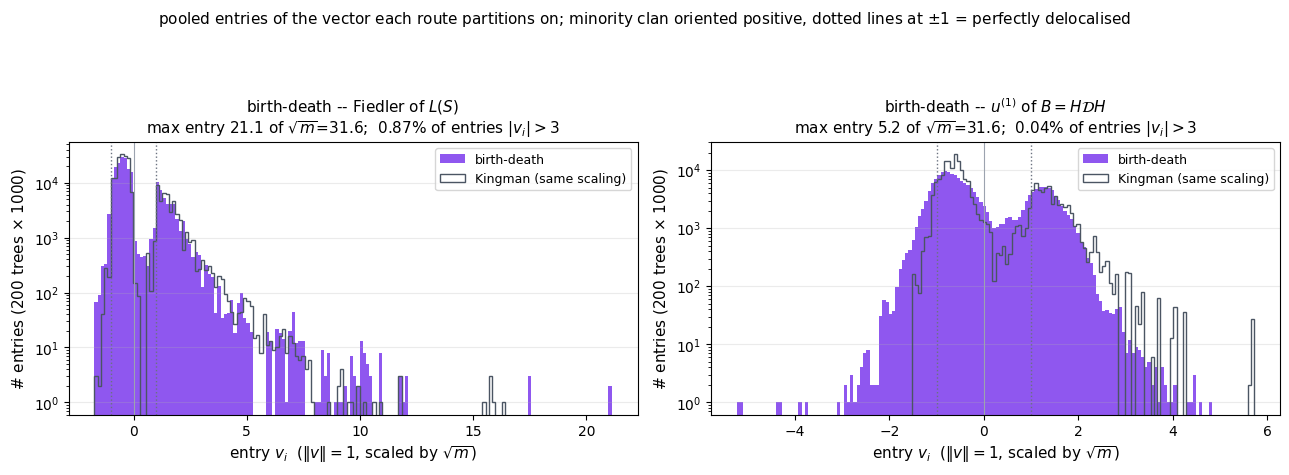

PR q25  PR med  PR q75 PR < 0.1
model       vector                                                       
Kingman     Fiedler of L(S)                0.149   0.382   0.649      20%
            u^{(1)} of B = H\mathcal{D}H   0.366   0.585   0.781       2%
birth-death Fiedler of L(S)                0.156   0.393   0.706      18%
            u^{(1)} of B = H\mathcal{D}H   0.456   0.602   0.725       0%

In [ ]:
VEC_CACHE = CDIR / f"vectors_sample_n{N}_L{SEQ_LEN}_R{R_SAMPLE}.npz"
cachedv = np.load(VEC_CACHE, allow_pickle=False)
assert np.array_equal(cachedv["ids"], sample_ids), (
    "vector cache ids do not match the draw; recomputing is ~17 min, so this is "
    "raised rather than silently recomputed")
vec_L, vec_B = cachedv["vec_L"], cachedv["vec_B"]

VEC_SPEC = [(vec_L, r"Fiedler of $L(S)$"), (vec_B, r"$u^{(1)}$ of $B = H\mathcal{D}H$")]
DELOC = 1.0                                     # entry of a perfectly spread vector

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, (V, vname) in zip(axes, VEC_SPEC):
    ent, ent_k = V[sel].ravel(), V[sel_k].ravel()
    vbins = np.linspace(min(ent.min(), ent_k.min()), max(ent.max(), ent_k.max()), 161)
    ax.hist(ent, bins=vbins, color=C_MOD[MODEL], alpha=0.85, edgecolor="none",
            label=MNAME)
    ax.hist(ent_k, bins=vbins, histtype="step", color="#4b5563", lw=1.0,
            label="Kingman (same scaling)")
    ax.set_yscale("log")                        # the tail is 1 entry against ~1e5
    for x in (-DELOC, DELOC):
        ax.axvline(x, color="#6b7280", ls=":", lw=1.0)
    ax.axvline(0, color="#9ca3af", lw=0.8)
    big = float(np.mean(np.abs(ent) > 3 * DELOC))
    ax.set_title(f"{MNAME} -- {vname}\nmax entry {np.abs(ent).max():.1f} of "
                 f"$\\sqrt{{m}}$={np.sqrt(N):.1f};  {100*big:.2f}% of entries $|v_i|>3$",
                 fontsize=11)
    ax.set_xlabel(r"entry $v_i$  ($\|v\|=1$, scaled by $\sqrt{m}$)", fontsize=11)
    ax.set_ylabel(f"# entries ({int(sel.sum())} trees $\\times$ {N})", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25, axis="y")
fig.suptitle("pooled entries of the vector each route partitions on; minority clan "
             "oriented positive, dotted lines at $\\pm1$ = perfectly delocalised",
             fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

# The same contrast as one number per tree: participation ratio PR = 1/(m * sum v_i^4)
# under the sqrt(m) scaling above, i.e. the fraction of leaves carrying the mass. PR
# near 1 is a vector spread over the whole tree; PR near 1/m is a vector living on a
# single leaf, which is the split that gives eta = m-1.
pr_rows = []
for mo, mname in MODELS:
    s = models == mo
    for V, vname in VEC_SPEC:
        pr = 1.0 / np.mean((V[s].astype(float) ** 2) ** 2, axis=1)      # in [1/m, 1]
        q = np.percentile(pr, [25, 50, 75])
        pr_rows.append({"model": mname, "vector": vname.replace("$", ""),
                        "PR q25": round(q[0], 3), "PR med": round(q[1], 3),
                        "PR q75": round(q[2], 3),
                        "PR < 0.1": f"{100*np.mean(pr < 0.1):.0f}%"})
pd.DataFrame(pr_rows).set_index(["model", "vector"])

### The birth–death numbers, in one place

The quantities the distance-route note quotes for this model. `δ_*` is the smallest
entry in absolute value of the vector a route partitions on, and the cached vectors
are already scaled by `√m`, so the minimum of `|entry|` **is** `√m δ_*`.

In [ ]:
print(f"--- {MNAME}: split agreement, {len(dfb)} trees ---")
same = np.isclose(dfb["eta_S"], dfb["eta_B"])
bs, bb = dfb["valid_S"], dfb["valid_B"]
print(f"  valid edge      L(S) {100*bs.mean():5.1f}%    B {100*bb.mean():5.1f}%")
print(f"  median eta      L(S) {dfb['eta_S'].median():5.2f}     B {dfb['eta_B'].median():5.2f}")
print(f"  both valid {int((bs & bb).sum()):4d}   only L(S) {int((bs & ~bb).sum()):4d}   "
      f"only B {int((~bs & bb).sum()):4d}   neither {int((~bs & ~bb).sum()):4d}")
print(f"  identical split picked by both: {100*same.mean():.0f}%")

print(f"\n--- {MNAME}: the two vectors, {R_SAMPLE} trees ---")
loc_rows = []
for V, vname in VEC_SPEC:
    for mo, mname in MODELS:
        A = np.abs(V[models == mo].astype(float))
        d = A.min(axis=1)                       # sqrt(m) * delta_*, one per tree
        mx = A.max(axis=1)                      # sqrt(m) * ||v||_inf
        loc_rows.append({
            "vector": vname.replace("$", ""), "model": mname,
            "sqrt(m) delta_* med": f"{np.median(d):.4g}",
            "q10": f"{np.percentile(d, 10):.4g}", "q90": f"{np.percentile(d, 90):.4g}",
            "sqrt(m) ||v||_inf med": f"{np.median(mx):.3g}",
        })
pd.DataFrame(loc_rows).set_index(["vector", "model"])

--- birth-death: split agreement, 1000 trees ---
  valid edge      L(S)  99.6%    B  55.5%
  median eta      L(S)  3.08     B  1.53
  both valid  553   only L(S)  443   only B    2   neither    2
  identical split picked by both: 33%

--- birth-death: the two vectors, 200 trees ---


sqrt(m) delta_* med        q10  \
vector                       model                                        
Fiedler of L(S)              Kingman                   0.521     0.2003   
                             birth-death              0.4054     0.1143   
u^{(1)} of B = H\mathcal{D}H Kingman                  0.3562    0.06793   
                             birth-death             0.02413  0.0003767   

                                             q90 sqrt(m) ||v||_inf med  
vector                       model                                      
Fiedler of L(S)              Kingman      0.8514                  1.95  
                             birth-death  0.7841                  1.97  
u^{(1)} of B = H\mathcal{D}H Kingman      0.6594                  1.59  
                             birth-death  0.3077                   1.8

## Recovery under sub-sampling, by tree size

Uniform sub-sampling of the operator each route reads, with the split rules the screen
at the top uses — `L(S)` Fiedler with k-means, `B = H D H` leading-|λ| with the sign
rule and mean imputation of the missing entries. Each route is scored by NMI against
**its own** full-matrix (`p = 1`) partition, so the curve measures how well
sub-sampling reproduces that route's answer; whether that answer was a real tree edge
is the validity table further up.

Two panels per route, the same pair the manuscript's recovery figures use:

- **NMI vs `p`**, one curve per `m` (median over trees, band = q25–q75).
- **`p̂⋆` vs `m`** on log–log, against one reference curve `C log m / m`. `C` is the
  **median of the per-point ratios** `p̂⋆ / (log m / m)` (`median_ratio_C`), not a
  least-squares fit — a linear fit is set almost entirely by the smallest trees. The
  panel prints `C` and the max/min spread of those ratios, which is the honest
  statement of how well one constant fits.

`p̂⋆` is the smallest grid `p` whose median NMI reaches 0.90; at 0.95 the read-off
lands on the flat top of the transition, where one noisy tree moves it a whole step.

Trees are `<model>_n<m>_000 … _0kk` — the deterministic index grid, one cache file per
`(model, m)`, so an interrupted run keeps every size it finished.

In [ ]:
# --- sweep configuration ------------------------------------------------------
# Adding a size to SW_M_GRID is enough: the tree count falls back to a default and
# the cost model interpolates, so nothing here raises on an unlisted m.
SW_M_GRID = [125, 250, 500, 1000, 2000, 4000]   # leaves per tree
SW_TREES_SET = {125: 20, 250: 20, 500: 20, 1000: 16, 2000: 6, 4000: 6}
SW_TREES_DEFAULT = 4                        # used for any m not listed above
SW_P_GRID = np.logspace(-4, 0, 17)          # 1e-4 .. 1, four points per decade
SW_REPS = 8                                 # independent sub-samples per (tree, p),
                                            # each scored on its own (see SW_AGG)
SW_SEQ_LEN = SEQ_LEN                        # 10^4 -- as everywhere else in this notebook
NMI_THR = 0.90                              # p* read-off; 0.95 lands on the flat top
SW_AGG = "perrep"                           # score each sub-sample, THEN average the
                                            # metric -- the same estimator on both routes

SW_TREES = {m: SW_TREES_SET.get(m, SW_TREES_DEFAULT) for m in SW_M_GRID}
SW_DIR = _root / "analysis" / "notebooks_cache" / "bd_model_exploration"
SW_TAG = f"L{SW_SEQ_LEN}_p{len(SW_P_GRID)}_r{SW_REPS}_{SW_AGG}"


def sw_cache(model, m):
    """One file per (model, m): an interrupted run keeps the sizes it finished."""
    return SW_DIR / f"sweep_{model}_n{m}_{SW_TAG}_t{SW_TREES[m]}.npz"


# Measured on this machine at L=10^4. The eigensolves dominate and steepen with m --
# 0.22 s at m=1000, 1.38 at 2000, 15.1 at 4000, i.e. about m^3.5 over the top octave,
# not the m^2.6 the lower sizes suggest. Any m in between is interpolated in log-log.
SW_SEC_PER_SOLVE = {125: 0.003, 250: 0.009, 500: 0.077, 1000: 0.223, 2000: 1.382,
                    4000: 15.11}                       # seconds per (tree, p, rep)
SW_SEC_PER_TREE_GEN = {125: 0.1, 250: 0.3, 500: 0.7, 1000: 2.1, 2000: 6.8, 4000: 34.7}


def _loglog(table, m):
    """Interpolate a measured cost table in log-log; clamps outside its range."""
    ks = np.array(sorted(table), float)
    return float(np.exp(np.interp(np.log(m), np.log(ks),
                                  np.log([table[int(k)] for k in ks]))))


def sw_cell_seconds(m):
    """Wall-clock for one (model, m) cell, both routes."""
    return SW_TREES[m] * (_loglog(SW_SEC_PER_SOLVE, m) * len(SW_P_GRID) * SW_REPS
                          + _loglog(SW_SEC_PER_TREE_GEN, m))


_todo = [(mo, m) for mo, _ in MODELS for m in SW_M_GRID if not sw_cache(mo, m).exists()]
print(f"m grid {SW_M_GRID}, trees {[SW_TREES[m] for m in SW_M_GRID]}, "
      f"{len(SW_P_GRID)} p x {SW_REPS} reps, both routes, both models")
for m in SW_M_GRID:
    flag = "" if m in SW_TREES_SET else f"  [no explicit count, using {SW_TREES_DEFAULT}]"
    print(f"  m={m:<5d} {SW_TREES[m]:>2d} trees   {sw_cell_seconds(m)/60:6.1f} min per model{flag}")
print(f"cached: {len(MODELS) * len(SW_M_GRID) - len(_todo)}/"
      f"{len(MODELS) * len(SW_M_GRID)} (model, m) cells")
print("all cached -- loads instantly" if not _todo
      else f"{len(_todo)} to compute: about "
           f"{sum(sw_cell_seconds(m) for _, m in _todo)/60:.0f} min")

m grid [125, 250, 500, 1000, 2000], trees [20, 20, 20, 16, 6], 17 p x 8 reps, both routes, both models
  m=125   20 trees      0.2 min per model
  m=250   20 trees      0.5 min per model
  m=500   20 trees      3.7 min per model
  m=1000  16 trees      8.6 min per model
  m=2000   6 trees     19.5 min per model
cached: 10/10 (model, m) cells
all cached -- loads instantly


In [ ]:
# Cold run: the B route is reused from the pre-per_rep caches when their ids match, so
# only the L(S) route recomputes (~13% of the cost).
#
# BOTH routes use per_rep: one sub-sample is one experiment, scored on its own, and the
# metric is averaged afterwards. bootstrap_p_sweep_simple does NOT do this -- it averages
# the sign-aligned Fiedler vectors and partitions once (avg_vector), which reduces the
# noise by ~sqrt(reps) before rounding and reads optimistic. src/utils/bpart_sweep_cache.py
# states the two are never to be pooled, so the L(S) loop is written out here instead.
from sklearn.metrics import normalized_mutual_info_score

from src.utils.bpart_sweep_cache import bpart_sweep_raw
from src.utils.partition_validity import check_partition_valid_in_tree
from src.utils.random_entries import _subsample_matrix_entries
from src.utils.screening import _tree_leaf_index
from src.utils.tree_ids import make_tree_id


def sweep_S_per_rep(S_i, u_ref, ref_int):
    """L(S) route, per_rep: subsample -> Fiedler -> align -> k-means -> NMI, per draw."""
    out = np.empty(SW_P_GRID.size)
    for j, p in enumerate(SW_P_GRID):
        if p >= 0.9999:
            out[j] = 1.0
            continue
        vals = []
        for r in range(SW_REPS):
            S_hat = _subsample_matrix_entries(S_i, float(p), seed=1_000_000 + 10_000 * j + r)
            try:
                f = compute_fiedler_from_laplacian(compute_laplacian(S_hat))
            except Exception:
                continue
            if np.dot(f, u_ref) < 0:
                f = -f
            part = np.asarray(_kmeans_bipartition(f, MIN_SPLIT)).astype(int)
            vals.append(normalized_mutual_info_score(ref_int, part))
        out[j] = float(np.mean(vals)) if vals else np.nan
    return out


def sweep_cell(model, m):
    """Both routes on ``SW_TREES[m]`` trees of size m, plus each route's p=1 validity."""
    ids = np.asarray([make_tree_id(model, i, m) for i in range(SW_TREES[m])], dtype="U")
    path = sw_cache(model, m)
    if path.exists():
        z = np.load(path, allow_pickle=False)
        if np.array_equal(z["ids"], ids) and np.allclose(z["p_values"], SW_P_GRID):
            return z["nmi_S"], z["nmi_B"], z["valid_S"], z["valid_B"]
    # the B route is already per_rep in the older caches -- reuse it rather than redo it
    legacy = SW_DIR / path.name.replace(f"_{SW_AGG}", "")
    nmi_B = None
    if legacy.exists():
        zl = np.load(legacy, allow_pickle=False)
        if np.array_equal(zl["ids"], ids) and np.allclose(zl["p_values"], SW_P_GRID):
            nmi_B = zl["nmi_B"]

    nmi_S = np.empty((ids.size, SW_P_GRID.size))
    nmi_B_new = np.empty_like(nmi_S)
    valid_S, valid_B = np.empty(ids.size), np.empty(ids.size)
    # Per-tree checkpoint: at m=4000 one tree is ~35 min, so a cell that only wrote at
    # the end would lose hours to an interrupt. Resume from whatever landed.
    part = path.with_suffix(".partial.npz")
    done = 0
    if part.exists():
        zp = np.load(part, allow_pickle=False)
        if np.array_equal(zp["ids"], ids) and np.allclose(zp["p_values"], SW_P_GRID):
            done = int(zp["done"])
            nmi_S[:done], nmi_B_new[:done] = zp["nmi_S"][:done], zp["nmi_B"][:done]
            valid_S[:done], valid_B[:done] = zp["valid_S"][:done], zp["valid_B"][:done]
            print(f"  {model} m={m}: resuming after {done}/{ids.size} trees")
    for i, tid in enumerate(ids):
        if i < done:
            continue
        S_i, labels, tree, D_i = make_generated(str(tid), seq_len=SW_SEQ_LEN)
        sidx = _tree_leaf_index(tree, labels)
        u = compute_fiedler_from_laplacian(compute_laplacian(S_i))
        ref = np.asarray(_kmeans_bipartition(u, MIN_SPLIT)).astype(bool)
        nmi_S[i] = sweep_S_per_rep(S_i, u, ref.astype(int))
        valid_S[i] = float(check_partition_valid_in_tree(tree, ref[sidx]))
        w = griffing_leading_eigvec(D_i, solver="lm_k1")
        valid_B[i] = float(check_partition_valid_in_tree(tree, (w >= 0)[sidx]))
        if nmi_B is None:
            raw = bpart_sweep_raw(D_i, list(SW_P_GRID), reps=SW_REPS, seed_base=1000 * i)
            nmi_B_new[i] = [float(np.mean(e["nmi"])) for e in raw["per_p"]]
        print(f"\r  {model} m={m}: {i+1}/{ids.size}  {tid}   ", end="")
        SW_DIR.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(part, ids=ids, p_values=SW_P_GRID, done=i + 1,
                           nmi_S=nmi_S, nmi_B=nmi_B_new,
                           valid_S=valid_S, valid_B=valid_B)
    if nmi_B is None:
        nmi_B = nmi_B_new
    SW_DIR.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(path, ids=ids, p_values=SW_P_GRID, nmi_S=nmi_S, nmi_B=nmi_B,
                       valid_S=valid_S, valid_B=valid_B)
    part.unlink(missing_ok=True)
    print(f"\r  wrote {path.name}" + " " * 30)
    return nmi_S, nmi_B, valid_S, valid_B


_order = sorted(((mo, m) for mo, _ in MODELS for m in SW_M_GRID),
                key=lambda t: (t[1], t[0] != MODEL))   # by size; bd first within a size
SW = {k: sweep_cell(*k) for k in _order}
print(f"{len(SW)} (model, m) cells ready")

10 (model, m) cells ready


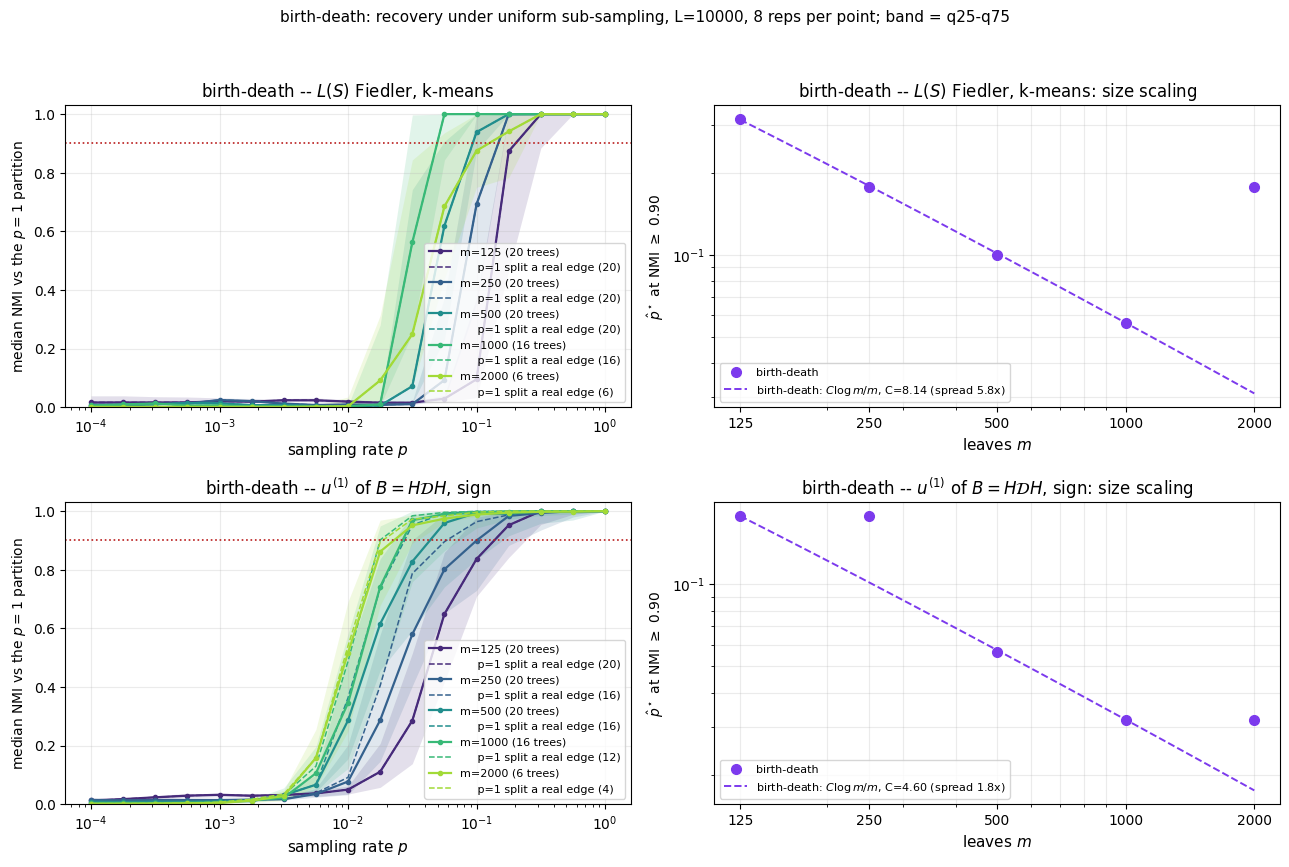

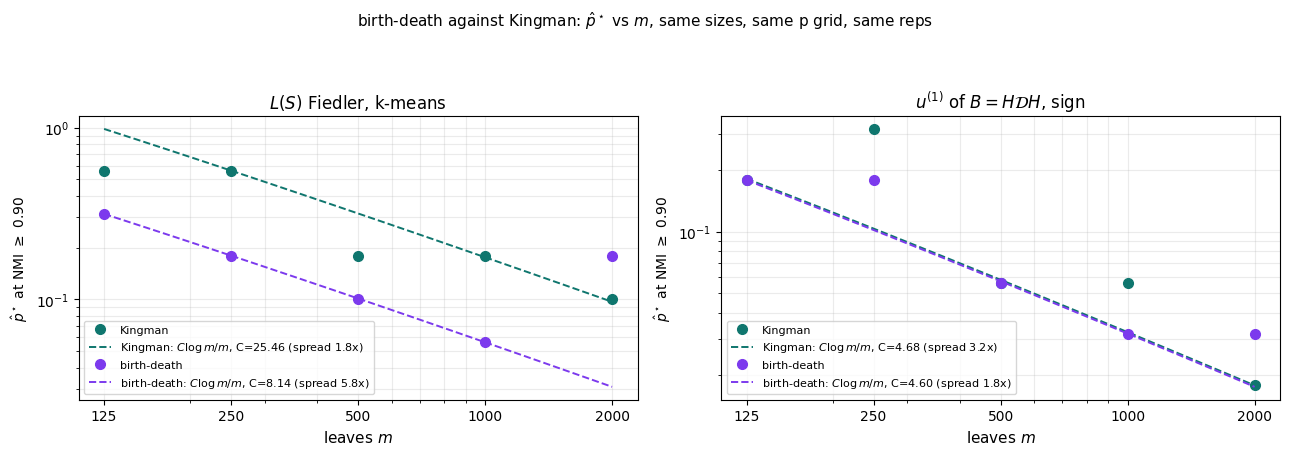

trees       p*  \
route                              model       m                      
L(S) Fiedler, k-means              Kingman     125      20  0.56234   
                                               250      20  0.56234   
                                               500      20  0.17783   
                                               1000     16  0.17783   
                                               2000      6  0.10000   
                                   birth-death 125      20  0.31623   
                                               250      20  0.17783   
                                               500      20  0.10000   
                                               1000     16  0.05623   
                                               2000      6  0.17783   
u^{(1)} of B = H\mathcal{D}H, sign Kingman     125      20  0.17783   
                                               250      20  0.31623   
                                               500      20  0.05623   
                                               1000     16  0.05623   
                                               2000      6  0.01778   
                                   birth-death 125      20  0.17783   
                                               250      20  0.17783   
                                               500      20  0.05623   
                                               1000     16  0.03162   
                                               2000      6  0.03162   

                                                     p* (valid only)  \
route                              model       m                       
L(S) Fiedler, k-means              Kingman     125           0.56234   
                                               250           0.56234   
                                               500           0.17783   
                                               1000          0.17783   
                                               2000          0.10000   
                                   birth-death 125           0.31623   
                                               250           0.17783   
                                               500           0.10000   
                                               1000          0.05623   
                                               2000          0.17783   
u^{(1)} of B = H\mathcal{D}H, sign Kingman     125           0.17783   
                                               250           0.17783   
                                               500           0.05623   
                                               1000          0.05623   
                                               2000          0.01778   
                                   birth-death 125           0.17783   
                                               250           0.10000   
                                               500           0.03162   
                                               1000          0.01778   
                                               2000          0.03162   

                                                    p=1 valid  NMI at p=0.01  
route                              model       m                              
L(S) Fiedler, k-means              Kingman     125       100%          0.023  
                                               250       100%          0.010  
                                               500       100%          0.005  
                                               1000      100%          0.004  
                                               2000      100%          0.003  
                                   birth-death 125       100%          0.019  
                                               250       100%          0.009  
                                               500       100%          0.004  
                                               1000      100%          0.003  
                                    

In [ ]:
from analysis.utils.sweep_plots_two_panel import median_ratio_C

SW_ROUTES = [(0, r"$L(S)$ Fiedler, k-means"),
             (1, r"$u^{(1)}$ of $B = H\mathcal{D}H$, sign")]


def p_star(med):
    """Smallest grid p whose median NMI reaches the threshold; nan if it never does."""
    ok = np.where(med >= NMI_THR)[0]
    return float(SW_P_GRID[ok[0]]) if ok.size else float("nan")


def med_nmi(model, m, route, valid_only=False):
    """Median NMI over trees; ``valid_only`` keeps trees whose p=1 split is a real edge."""
    nmi, keep = SW[(model, m)][route], SW[(model, m)][2 + route].astype(bool)
    Y = nmi[keep] if valid_only else nmi
    return np.median(Y, axis=0) if Y.size else np.full(SW_P_GRID.size, np.nan)


def draw_nmi_panel(ax, model, route):
    """One curve per m, dark to light with increasing size."""
    ramp = plt.get_cmap("viridis")(np.linspace(0.12, 0.86, len(SW_M_GRID)))
    for col, m in zip(ramp, SW_M_GRID):
        Y = SW[(model, m)][route]
        q1, q3 = np.percentile(Y, [25, 75], axis=0)
        ax.fill_between(SW_P_GRID, q1, q3, color=col, alpha=0.15, lw=0)
        nv = int(SW[(model, m)][2 + route].sum())
        ax.plot(SW_P_GRID, np.median(Y, axis=0), "o-", ms=3, lw=1.6, color=col,
                label=f"m={m} ({Y.shape[0]} trees)")
        ax.plot(SW_P_GRID, med_nmi(model, m, route, valid_only=True), "--", lw=1.1,
                color=col, label=f"     p=1 split a real edge ({nv})")
    ax.axhline(NMI_THR, color="#b91c1c", ls=":", lw=1.2)
    ax.set_xscale("log")
    ax.set_xlabel("sampling rate $p$", fontsize=11)
    ax.set_ylabel("median NMI vs the $p=1$ partition", fontsize=10)
    ax.set_ylim(0, 1.03)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="lower right")


def draw_scale_panel(ax, models, route):
    """p* vs m, and ONE reference curve C log m / m per model."""
    for mo, mname in [(a, b) for a, b in MODELS if a in models]:
        xs = np.array(SW_M_GRID, float)
        ys = np.array([p_star(med_nmi(mo, m, route)) for m in SW_M_GRID])
        ok = np.isfinite(ys)
        ax.plot(xs[ok], ys[ok], "o", ms=7, color=C_MOD[mo], label=mname)
        if ok.sum() >= 2:
            C, spread = median_ratio_C(xs[ok], ys[ok])
            grid = np.logspace(np.log10(xs.min()), np.log10(xs.max()), 60)
            ax.plot(grid, C * np.log(grid) / grid, "--", lw=1.4, color=C_MOD[mo],
                    label=f"{mname}: $C\\log m/m$, C={C:.2f} (spread {spread:.1f}x)")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("leaves $m$", fontsize=11)
    ax.set_ylabel(r"$\hat p^\star$ at NMI $\geq$ " + f"{NMI_THR:.2f}", fontsize=10)
    ax.set_xticks(SW_M_GRID)
    ax.set_xticklabels([str(m) for m in SW_M_GRID])
    ax.grid(alpha=0.25, which="both")
    ax.legend(fontsize=8, loc="lower left")


# --- birth-death alone: NMI vs p, and the p* scaling, one row per route
fig, axes = plt.subplots(len(SW_ROUTES), 2, figsize=(13, 4.4 * len(SW_ROUTES)))
for r, (route, name) in enumerate(SW_ROUTES):
    draw_nmi_panel(axes[r, 0], MODEL, route)
    draw_scale_panel(axes[r, 1], {MODEL}, route)
    axes[r, 0].set_title(f"{MNAME} -- {name}", fontsize=12)
    axes[r, 1].set_title(f"{MNAME} -- {name}: size scaling", fontsize=12)
fig.suptitle(f"{MNAME}: recovery under uniform sub-sampling, L={SW_SEQ_LEN}, "
             f"{SW_REPS} reps per point; band = q25-q75", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- against Kingman: the size scaling only, same trees per size, same grid
fig, axes = plt.subplots(1, len(SW_ROUTES), figsize=(13, 4.6))
for ax, (route, name) in zip(axes, SW_ROUTES):
    draw_scale_panel(ax, {"kingman", MODEL}, route)
    ax.set_title(name, fontsize=12)
fig.suptitle(f"{MNAME} against Kingman: $\\hat p^\\star$ vs $m$, same sizes, "
             f"same p grid, same reps", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

pd.DataFrame([{"route": name.replace("$", ""), "model": mname, "m": m,
               "trees": SW_TREES[m],
               "p*": round(p_star(med_nmi(mo, m, route)), 5),
               "p* (valid only)": round(p_star(med_nmi(mo, m, route, True)), 5),
               "p=1 valid": f"{100*SW[(mo, m)][2+route].mean():.0f}%",
               "NMI at p=0.01": round(float(
                   med_nmi(mo, m, route)[np.argmin(np.abs(SW_P_GRID - 0.01))]), 3)}
              for route, name in SW_ROUTES for mo, mname in MODELS for m in SW_M_GRID]
             ).set_index(["route", "model", "m"])

## Assumption audit for `docs/overleafs/no_block/`

Clans are the k-means split of the unit-norm Fiedler vector $v$ of $L(S)$; $B$ is the
larger clan. One row per tree, same $(model, m, index)$ grid as the sweep above.

| symbol | definition |
|---|---|
| $S_{\rm in}^{\min}$ | $\min_{i \neq j,\ \text{same clan}} S_{ij}$ |
| $S_{\rm out}^{\min}$, $S_{\rm out}^{\max}$ | $\min$, $\max$ over cross-clan pairs of $S_{ij}$ |
| $\eta$ | larger clan / smaller clan |
| $\rho$ | $(S_{\rm in}^{\min} - S_{\rm out}^{\max}) - (S_{\rm out}^{\max} - S_{\rm out}^{\min})$ |
| slack | $\rho - \eta\,S_{\rm out}^{\max}$; condition C1 holds iff slack $> 0$ |
| slack$_q$ | slack with $q_{01}$ of within-clan pairs for $S_{\rm in}^{\min}$ and $q_{99}$ of cross-clan pairs for $S_{\rm out}^{\max}$ |
| $\varepsilon$ | $\max_{i,j\ \text{same clan}} |v_i - v_j|$; the assumption is $\varepsilon \leq \mathcal{O}(1/\sqrt{m})$, i.e. $\sqrt{m}\,\varepsilon = \mathcal{O}(1)$ |
| $\varepsilon_q$ | $\varepsilon$ with $q_{99} - q_{01}$ in place of $\max - \min$, per clan |
| $c_B$ | $\mathrm{mean}_{i \in B} |v_i|$; Stage 4 assumes $c_B = \Theta(1/\sqrt{m})$ |
| $\delta_*$ | $\min_i |v_i|$, the entry-wise margin |

In [ ]:
# --- audit configuration ------------------------------------------------------
AU_M_GRID = SW_M_GRID                       # same sizes as the sweep
AU_TREES = SW_TREES                         # same trees per size
AU_SEQ_LEN = SW_SEQ_LEN
AU_CACHE = SW_DIR / f"audit_L{AU_SEQ_LEN}_m{'-'.join(map(str, AU_M_GRID))}.npz"

AU_FIELDS = ("m", "eta", "s_in_min", "s_out_min", "s_out_max", "rho", "slack",
             "slack_q", "eps", "eps_q", "c_B", "delta_star", "valid")
print(f"{sum(AU_TREES[m] for m in AU_M_GRID) * len(MODELS)} trees over m={AU_M_GRID}\n"
      f"cache: {AU_CACHE.name}\n"
      f"{'cached -- loads instantly' if AU_CACHE.exists() else 'cold -- about 5 min'}")

164 trees over m=[125, 250, 500, 1000, 2000]
cache: audit_L10000_m125-250-500-1000-2000.npz
cached -- loads instantly


In [ ]:
from src.utils.partition_validity import check_partition_valid_in_tree
from src.utils.screening import _tree_leaf_index
from src.utils.tree_ids import make_tree_id


def audit_one(tid):
    """The scalars defined above, for one tree."""
    S_i, labels, tree, _ = make_generated(str(tid), seq_len=AU_SEQ_LEN)
    m = S_i.shape[0]
    v = compute_fiedler_from_laplacian(compute_laplacian(S_i))
    v = v / np.linalg.norm(v)                       # unit norm: the note's v^(2)
    part = np.asarray(_kmeans_bipartition(v, MIN_SPLIT)).astype(bool)
    A, B = ~part, part
    if A.sum() < B.sum():                           # B is the larger clan
        A, B = B, A
    off = ~np.eye(m, dtype=bool)
    within = S_i[(np.outer(A, A) | np.outer(B, B)) & off]
    cross = S_i[np.outer(A, B) | np.outer(B, A)]

    s_in_min, s_out_min, s_out_max = within.min(), cross.min(), cross.max()
    eta = float(max(A.sum(), B.sum())) / max(min(A.sum(), B.sum()), 1)
    rho = (s_in_min - s_out_max) - (s_out_max - s_out_min)
    # relaxed: allow the worst 1% of within-clan and the top 1% of cross-clan pairs
    s_in_q, s_out_q = np.percentile(within, 1), np.percentile(cross, 99)
    rho_q = (s_in_q - s_out_q) - (s_out_q - s_out_min)
    return [m, eta, s_in_min, s_out_min, s_out_max, rho, rho - eta * s_out_max,
            rho_q - eta * s_out_q,
            max(np.ptp(v[A]), np.ptp(v[B])),
            max(float(np.diff(np.percentile(v[c], [1, 99]))[0]) for c in (A, B)),
            np.abs(v[B]).mean(), np.abs(v).min(),
            float(check_partition_valid_in_tree(tree, part[_tree_leaf_index(tree, labels)]))]


if AU_CACHE.exists():
    z = np.load(AU_CACHE, allow_pickle=False)
    au_ids, AU = z["ids"], z["rows"]
    print(f"loaded {AU_CACHE.name}")
else:
    au_ids = np.asarray([make_tree_id(mo, i, m) for mo, _ in MODELS
                         for m in AU_M_GRID for i in range(AU_TREES[m])], dtype="U")
    AU = np.empty((au_ids.size, len(AU_FIELDS)))
    for i, tid in enumerate(au_ids):
        AU[i] = audit_one(tid)
        print(f"\r{i+1}/{au_ids.size}  {tid}   ", end="")
    SW_DIR.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(AU_CACHE, ids=au_ids, rows=AU)
    print(f"\nwrote {AU_CACHE.name}")

au = pd.DataFrame(AU, columns=list(AU_FIELDS))
au["model"] = [str(t).rsplit("_n", 1)[0] for t in au_ids]
au["m"] = au["m"].astype(int)
au["sqrt_m_eps"] = np.sqrt(au["m"]) * au["eps"]
au["sqrt_m_eps_q"] = np.sqrt(au["m"]) * au["eps_q"]
au["sqrt_m_c_B"] = np.sqrt(au["m"]) * au["c_B"]
au["sqrt_m_delta"] = np.sqrt(au["m"]) * au["delta_star"]
print(f"{len(au)} trees audited")

loaded audit_L10000_m125-250-500-1000-2000.npz
164 trees audited


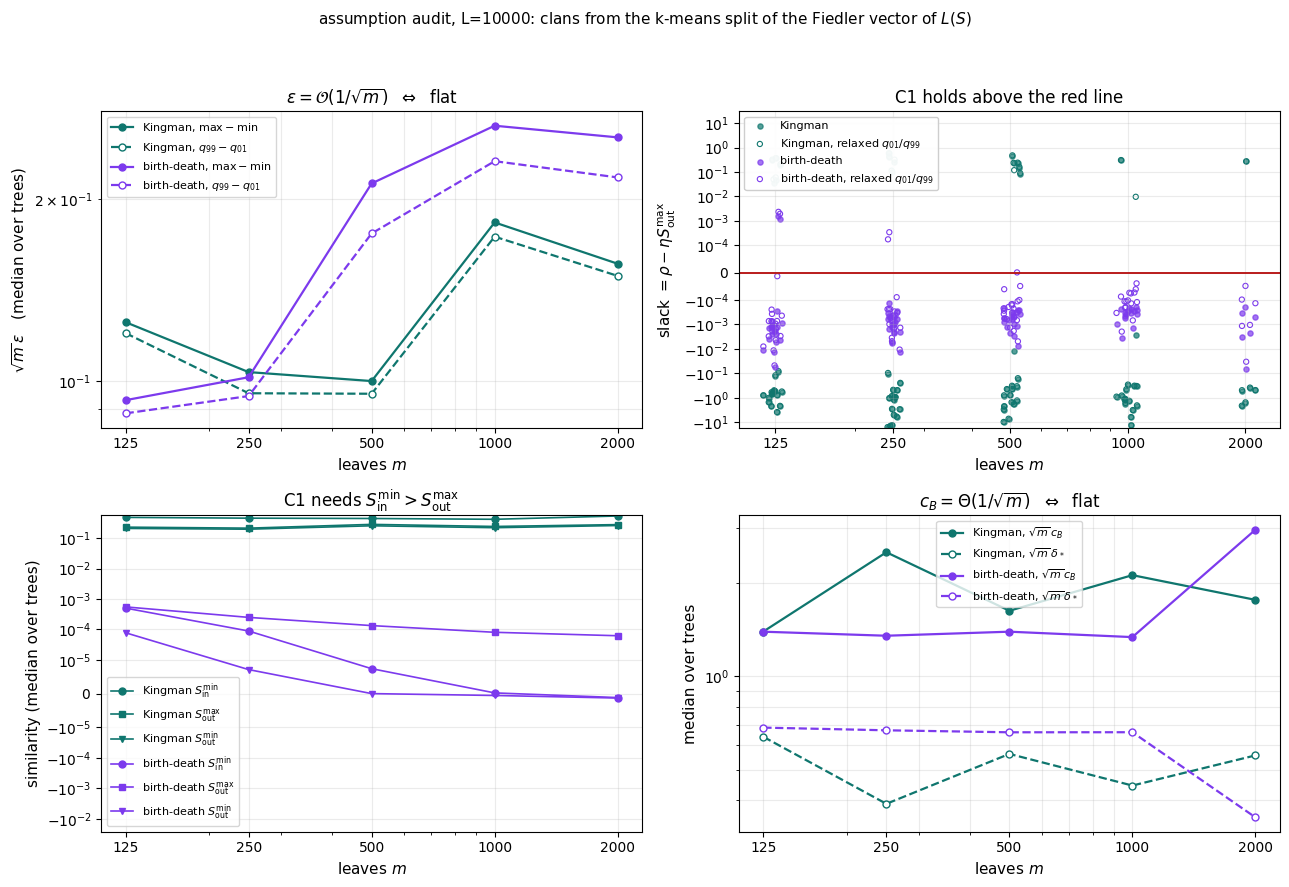

trees C1 holds C1 relaxed holds  sqrt(m) eps_q  sqrt(m) c_B  \
model       m                                                                   
Kingman     125      20      25%              25%          0.120        1.395   
            250      20      20%              20%          0.095        2.510   
            500      20      25%              30%          0.095        1.627   
            1000     16       6%              12%          0.173        2.118   
            2000      6      17%              17%          0.149        1.764   
birth-death 125      20      10%              10%          0.088        1.393   
            250      20       0%              10%          0.094        1.352   
            500      20       0%               5%          0.175        1.393   
            1000     16       0%               0%          0.231        1.339   
            2000      6       0%               0%          0.217        2.966   

                  sqrt(m) delta_*  median eta  
model       m                                  
Kingman     125             0.639        1.95  
            250             0.389        6.32  
            500             0.563        2.69  
            1000            0.446        4.49  
            2000            0.557        3.11  
birth-death 125             0.685        1.94  
            250             0.671        1.89  
            500             0.661        1.96  
            1000            0.662        1.81  
            2000            0.352        9.18

In [ ]:
def by_size(model, col, stat="median"):
    g = au[au.model == model].groupby("m")[col]
    return np.array(AU_M_GRID, float), np.array([getattr(g.get_group(m), stat)()
                                                 for m in AU_M_GRID])


fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) the fluctuation assumption: sqrt(m)*eps flat <=> eps = O(1/sqrt(m))
ax = axes[0, 0]
for mo, mname in MODELS:
    for col, ls, lab in (("sqrt_m_eps", "-", r"$\max-\min$"),
                         ("sqrt_m_eps_q", "--", r"$q_{99}-q_{01}$")):
        x, y = by_size(mo, col)
        ax.plot(x, y, "o" + ls, ms=5, lw=1.6, color=C_MOD[mo],
                mfc="white" if ls == "--" else C_MOD[mo], label=f"{mname}, {lab}")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks(AU_M_GRID); ax.set_xticklabels(map(str, AU_M_GRID))
ax.set_xlabel("leaves $m$", fontsize=11)
ax.set_ylabel(r"$\sqrt{m}\,\varepsilon$   (median over trees)", fontsize=11)
ax.set_title(r"$\varepsilon = \mathcal{O}(1/\sqrt{m})$  $\Leftrightarrow$  flat", fontsize=12)
ax.grid(alpha=0.25, which="both"); ax.legend(fontsize=8)

# (b) condition C1: the slack itself, per tree, against zero
ax = axes[0, 1]
for mo, mname in MODELS:
    d = au[au.model == mo]
    jit = np.exp(np.random.default_rng(0).normal(0, 0.03, len(d)))
    ax.scatter(d["m"] * jit, d["slack"], s=14, color=C_MOD[mo], alpha=0.7, label=mname)
    ax.scatter(d["m"] * jit, d["slack_q"], s=14, facecolor="none",
               edgecolor=C_MOD[mo], lw=0.8, label=f"{mname}, relaxed $q_{{01}}/q_{{99}}$")
ax.axhline(0, color="#b91c1c", lw=1.4)
ax.set_xscale("log"); ax.set_yscale("symlog", linthresh=1e-4)
ax.set_xticks(AU_M_GRID); ax.set_xticklabels(map(str, AU_M_GRID))
ax.set_xlabel("leaves $m$", fontsize=11)
ax.set_ylabel(r"slack $= \rho - \eta S_{\rm out}^{\max}$", fontsize=11)
ax.set_ylim(top=30)                             # headroom so the legend clears the cloud
ax.set_title("C1 holds above the red line", fontsize=12)
ax.grid(alpha=0.25); ax.legend(fontsize=8, loc="upper left", framealpha=0.95)

# (c) why: the three similarity bounds on one axis
ax = axes[1, 0]
for mo, mname in MODELS:
    for col, mk, lab in (("s_in_min", "o", r"$S_{\rm in}^{\min}$"),
                         ("s_out_max", "s", r"$S_{\rm out}^{\max}$"),
                         ("s_out_min", "v", r"$S_{\rm out}^{\min}$")):
        x, y = by_size(mo, col)
        ax.plot(x, y, mk + "-", ms=5, lw=1.2, color=C_MOD[mo], label=f"{mname} {lab}")
ax.set_xscale("log"); ax.set_yscale("symlog", linthresh=1e-5)
ax.set_xticks(AU_M_GRID); ax.set_xticklabels(map(str, AU_M_GRID))
ax.set_xlabel("leaves $m$", fontsize=11)
ax.set_ylabel("similarity (median over trees)", fontsize=11)
ax.set_title(r"C1 needs $S_{\rm in}^{\min} > S_{\rm out}^{\max}$", fontsize=12)
ax.grid(alpha=0.25); ax.legend(fontsize=8)

# (d) the Stage 4 margin quantities
ax = axes[1, 1]
for mo, mname in MODELS:
    for col, ls, lab in (("sqrt_m_c_B", "-", r"$\sqrt{m}\,c_B$"),
                         ("sqrt_m_delta", "--", r"$\sqrt{m}\,\delta_*$")):
        x, y = by_size(mo, col)
        ax.plot(x, y, "o" + ls, ms=5, lw=1.6, color=C_MOD[mo],
                mfc="white" if ls == "--" else C_MOD[mo], label=f"{mname}, {lab}")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks(AU_M_GRID); ax.set_xticklabels(map(str, AU_M_GRID))
ax.set_xlabel("leaves $m$", fontsize=11)
ax.set_ylabel("median over trees", fontsize=11)
ax.set_title(r"$c_B = \Theta(1/\sqrt{m})$  $\Leftrightarrow$  flat", fontsize=12)
ax.grid(alpha=0.25, which="both"); ax.legend(fontsize=8)

fig.suptitle(f"assumption audit, L={AU_SEQ_LEN}: clans from the k-means split of the "
             f"Fiedler vector of $L(S)$", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

rows = []
for mo, mname in MODELS:
    for m in AU_M_GRID:
        d = au[(au.model == mo) & (au.m == m)]
        rows.append({"model": mname, "m": m, "trees": len(d),
                     "C1 holds": f"{100*(d['slack'] > 0).mean():.0f}%",
                     "C1 relaxed holds": f"{100*(d['slack_q'] > 0).mean():.0f}%",
                     "sqrt(m) eps_q": round(float(d["sqrt_m_eps_q"].median()), 3),
                     "sqrt(m) c_B": round(float(d["sqrt_m_c_B"].median()), 3),
                     "sqrt(m) delta_*": round(float(d["sqrt_m_delta"].median()), 3),
                     "median eta": round(float(d["eta"].median()), 2)})
pd.DataFrame(rows).set_index(["model", "m"])

### Against the predicted rate

$p = \Omega\!\left(\dfrac{\log m}{m} + \varepsilon^2 \log m\right)$: the two terms
evaluated with the measured $\varepsilon_q$, beside the measured $\hat p^\star$ of the
$L(S)$ route.

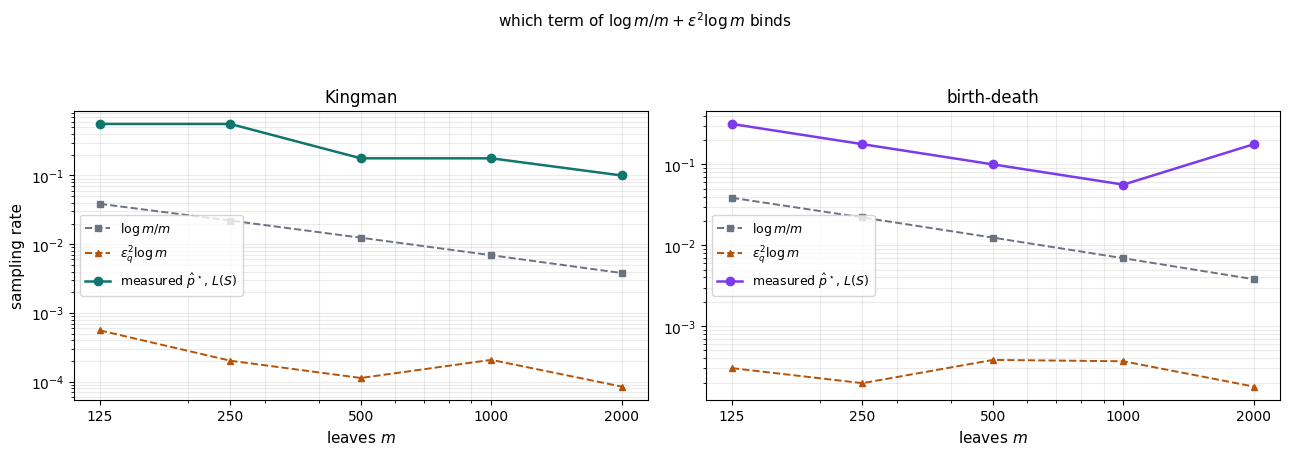

Kingman       eps_q ~ m^-0.35  (the assumption needs -0.50)
              sqrt(m) eps_q  = [0.12  0.095 0.095 0.173 0.149]
              (log m/m) / (eps^2 log m) = [ 69. 110. 110.  33.  45.]  over m=[125, 250, 500, 1000, 2000]
birth-death   eps_q ~ m^-0.11  (the assumption needs -0.50)
              sqrt(m) eps_q  = [0.088 0.094 0.175 0.231 0.217]
              (log m/m) / (eps^2 log m) = [128. 112.  33.  19.  21.]  over m=[125, 250, 500, 1000, 2000]


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, (mo, mname) in zip(axes, MODELS):
    x = np.array(AU_M_GRID, float)
    eps_q = np.array([au[(au.model == mo) & (au.m == m)]["eps_q"].median()
                      for m in AU_M_GRID])
    ps = np.array([p_star(med_nmi(mo, m, 0)) for m in AU_M_GRID])   # route 0 = L(S)
    ax.plot(x, np.log(x) / x, "s--", ms=5, lw=1.4, color="#6b7280",
            label=r"$\log m / m$")
    ax.plot(x, eps_q ** 2 * np.log(x), "^--", ms=5, lw=1.4, color="#b45309",
            label=r"$\varepsilon_q^2 \log m$")
    ax.plot(x, ps, "o-", ms=6, lw=1.8, color=C_MOD[mo],
            label=r"measured $\hat p^\star$, $L(S)$")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(AU_M_GRID); ax.set_xticklabels(map(str, AU_M_GRID))
    ax.set_xlabel("leaves $m$", fontsize=11)
    ax.set_title(mname, fontsize=12)
    ax.grid(alpha=0.25, which="both"); ax.legend(fontsize=9)
axes[0].set_ylabel("sampling rate", fontsize=11)
fig.suptitle(r"which term of $\log m/m + \varepsilon^2 \log m$ binds", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# How fast the intra-clan fluctuation decays, and by how much the second term of the
# rate is beaten at each size. The exponent is a 5-point fit, so it is a description
# of this grid, not an asymptotic claim; no crossover is extrapolated from it -- with
# 0.5 + a in the denominator that extrapolation swings by orders of magnitude.
for mo, mname in MODELS:
    e = np.array([au[(au.model == mo) & (au.m == m)]["eps_q"].median()
                  for m in AU_M_GRID])
    a = float(np.polyfit(np.log(AU_M_GRID), np.log(e), 1)[0])
    x = np.array(AU_M_GRID, float)
    ratio = (np.log(x) / x) / (e ** 2 * np.log(x))      # first term / second term
    print(f"{mname:<13s} eps_q ~ m^{a:+.2f}  (the assumption needs -0.50)\n"
          f"{'':13s} sqrt(m) eps_q  = {np.round(np.sqrt(x) * e, 3)}\n"
          f"{'':13s} (log m/m) / (eps^2 log m) = {np.round(ratio, 0)}  over m={AU_M_GRID}")
